In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import numpy as np

from datetime import datetime
from time import time

# Enable 64-bit by default for torch
torch.set_default_dtype(torch.float32)

## Evaluating on OOD

In [2]:
usps_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

usps_test_ds = datasets.USPS(
    root="../datasets",
    train=False,
    download=True,
    transform=usps_transform,
)

usps_loader = DataLoader(
    usps_test_ds,
    batch_size=100,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"USPS test samples: {len(usps_test_ds)}")

USPS test samples: 2007


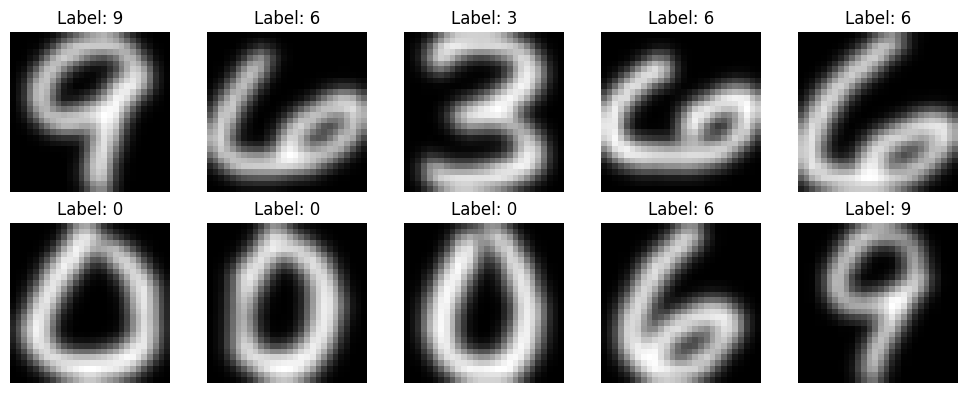

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = usps_test_ds[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
from onnx2pytorch import ConvertModel

import json_to_pytorch

import attack

In [14]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model)

In [20]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu_sampled.json", double_precision=False)

In [21]:
reference_model

ConvertModel(
  (Flatten_/flatten/Flatten_output_0): Flatten()
  (Gemm_/input/Gemm_output_0): Linear(in_features=784, out_features=256, bias=True)
  (Gelu_/gelu0/Gelu_output_0): GELU(approximate='none')
  (Gemm_/fc1/Gemm_output_0): Linear(in_features=256, out_features=256, bias=True)
  (Gelu_/gelu1/Gelu_output_0): GELU(approximate='none')
  (Gemm_/fc2/Gemm_output_0): Linear(in_features=256, out_features=256, bias=True)
  (Gelu_/gelu2/Gelu_output_0): GELU(approximate='none')
  (Gemm_/fc3/Gemm_output_0): Linear(in_features=256, out_features=256, bias=True)
  (Gelu_/gelu3/Gelu_output_0): GELU(approximate='none')
  (Gemm_output): Linear(in_features=256, out_features=10, bias=True)
)

In [22]:
#adv = attack.Adversary(attacks_iter=2, attack_restarts=2, attack_epsilon=10.0/255.0)
#adv = attack.AffineAdversary(attacks_iter=2, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2)
adv = attack.NoisyAffineAdversary(attacks_iter=4, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2, epsilon_noise=5.0/255.0)

In [23]:
#adv.loss_strategy = attack.InternalMaxLoss("Gelu_/gelu2/Gelu_output_0", "reference_model", "input")
adv.loss_strategy = attack.InternalMaxLoss("2", "test_model", "input")

### Sampled Bounds

In [24]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, usps_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [25]:
adv_examples = robust_eval_results_sampled["adv_examples"]

In [26]:
robust_eval_results_sampled["adv_examples"] = None
robust_eval_results_sampled

{'normal_loss_ref': 0.021542124862271753,
 'normal_loss_test': nan,
 'adv_loss_ref': 0.033132755999904874,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.5710014947683109,
 'normal_acc_test': 0.5241654210264076,
 'adv_acc_ref': 0.4289985052316891,
 'adv_acc_test': 0.33482810164424515,
 'normal_eq': 0.9481813652217239,
 'adv_eq': 0.8799202790234181,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.051818634778276036,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.12007972097658197,
 'total': 2007,
 'adv_examples': None}

Found 241 changed samples. Displaying...


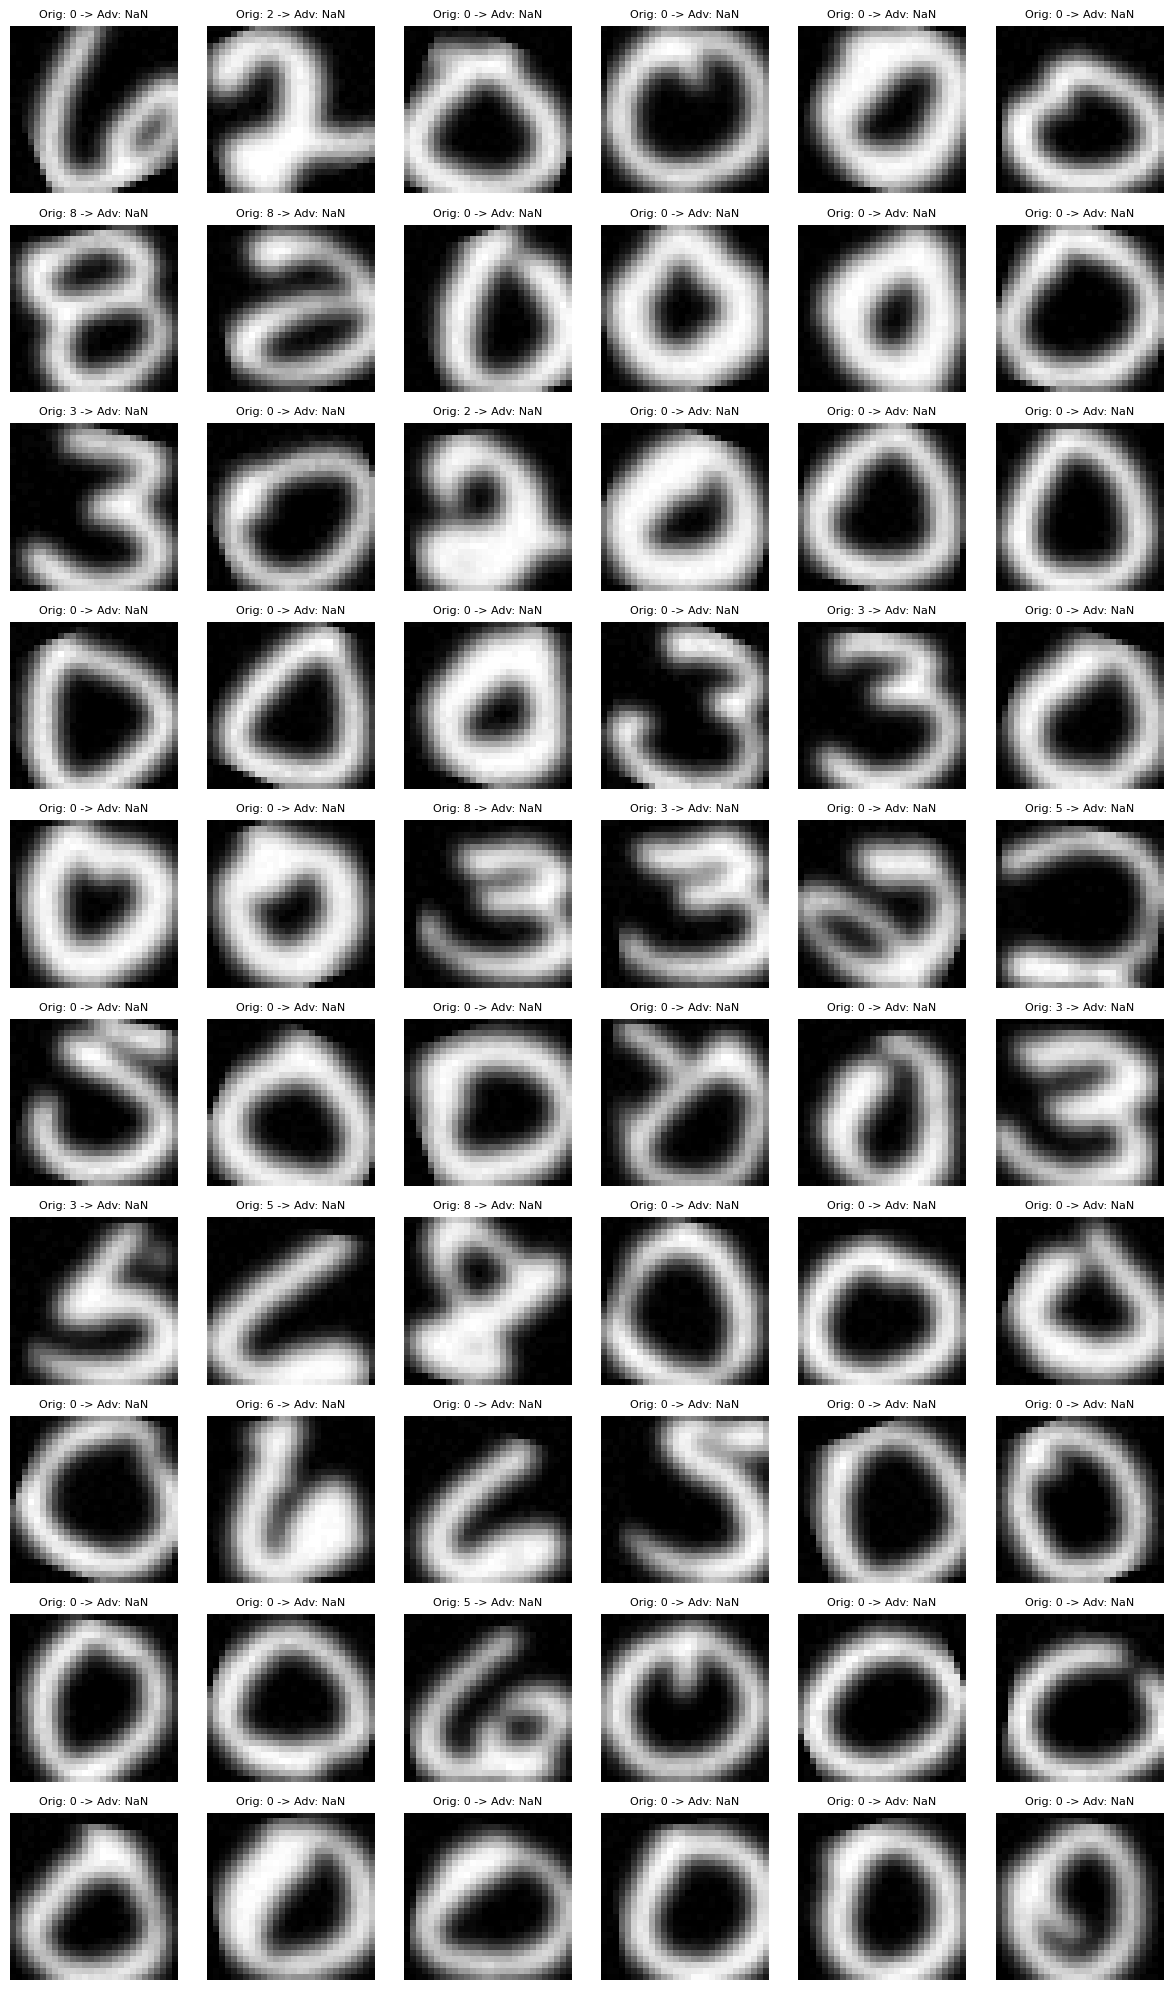

In [27]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 10)  # Limit to 5 rows for better visualization
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [28]:
# Save figure
fig.savefig("mnist_vae_ood_adv_examples_gelu_sampled_32.png", dpi=300)

Found 241 changed samples. Displaying...


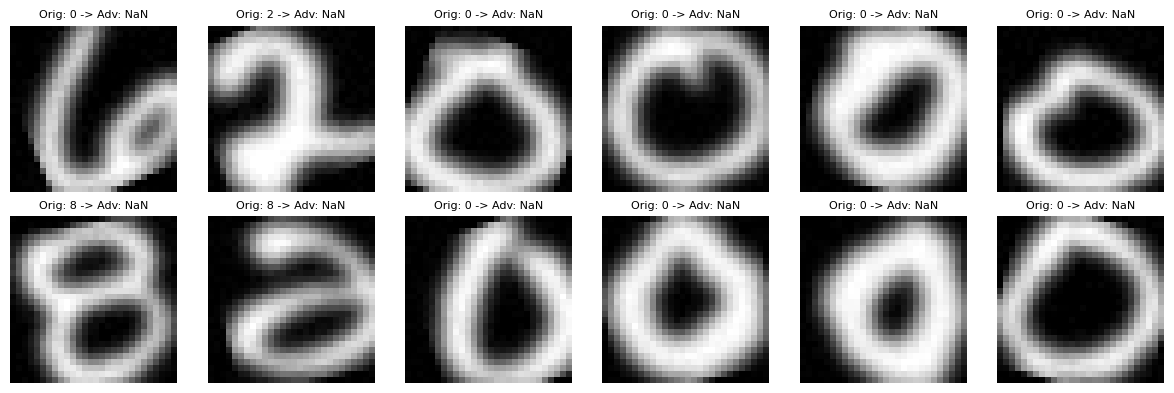

In [29]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 2)  # Limit to 5 rows for better visualization
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
# Save figure
fig.savefig("mnist_vae_ood_adv_examples_gelu_sampled_2rows_32.png", dpi=300)

Found 241 changed samples. Displaying...


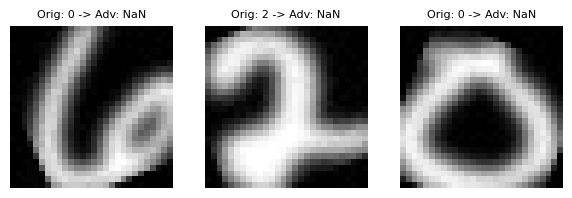

In [31]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 1)  # Limit to 5 rows for better visualization
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [32]:
# Save figure
fig.savefig("mnist_vae_ood_adv_examples_gelu_sampled_small_32.png", dpi=300)

### Proven Bounds

In [44]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu.json", double_precision=False)

In [45]:
test_model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ChebyshevPoly()
  (3): Linear(in_features=256, out_features=256, bias=True)
  (4): ChebyshevPoly()
  (5): Linear(in_features=256, out_features=256, bias=True)
  (6): ChebyshevPoly()
  (7): Linear(in_features=256, out_features=256, bias=True)
  (8): ChebyshevPoly()
  (9): Linear(in_features=256, out_features=10, bias=True)
)

In [46]:
robust_eval_results = attack.robust_eval(reference_model, test_model, usps_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [47]:
adv_examples_proven = robust_eval_results["adv_examples"]

In [48]:
robust_eval_results["adv_examples"] = None
robust_eval_results

{'normal_loss_ref': 0.021542124862271753,
 'normal_loss_test': 0.021542038915165634,
 'adv_loss_ref': 0.034115922587631825,
 'adv_loss_test': 0.034116005861883916,
 'normal_acc_ref': 0.5710014947683109,
 'normal_acc_test': 0.5710014947683109,
 'adv_acc_ref': 0.3328350772296961,
 'adv_acc_test': 0.3323368211260588,
 'normal_eq': 1.0,
 'adv_eq': 0.9995017438963627,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.0,
 'total': 2007,
 'adv_examples': None}

Found 1 changed samples. Displaying...


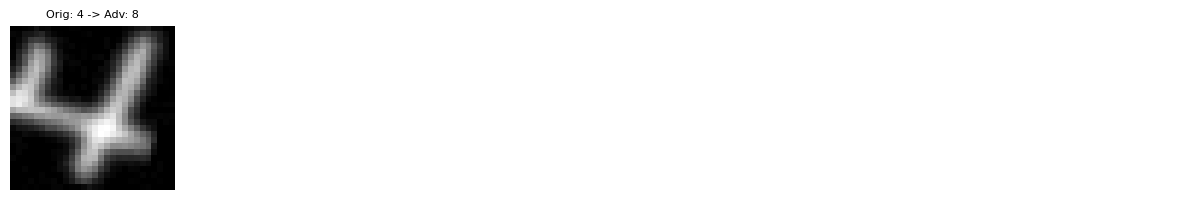

In [51]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples_proven:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 10)  # Limit to 5 rows for better visualization
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()